## **6.1.5 ResNet**

>- 딥러닝 파이토치 교과서 p.312-340
>- 논문: Deep Residual Learning for Image Recognition

깊어진 신경망을 효과적으로 학습하기 위해 residual 개념을 고안함. residual블록은 기울기가 잘 전파되도록 숏컷을 만들어 기울기 소멸 문제 방지함

- 합성곱층을 하나의 '블록'으로 묶음 = residual 블록 -> 블록을 여러 개 쌓은 것이 ResNet
  - 계층을 쌓을수록 파라미터가 증가하는 문제 -> bottleneck 블록으로 해결
  - Identity 블록: 입력과 출력의 차원이 같은 것
  - 합성곱 블록(projection shortcut): 입력 및 출력의 차원이 동일하지 않고 입력의 차원을 출력에 맞춰 변경해야하는 것
  
  ```
  def forward(self, x):
  i = x
  x = self.conv1(x)
  x = self.bn1(x)
  x = self.relu(x)
  x = self.conv2(x)
  x = self.bn2(x)

  if self.downsample is not None:
    i = self.downsample(i) # 다운샘플 적용

  x += I # 아이덴티티 매핑 적용
  x = self.relu(x)
  return x
  ```


- 기본적으로 VGG19 구조를 뼈대로 하고, 합성곱층들을 추가해 깊게 한 후 숏컷들을 추가함


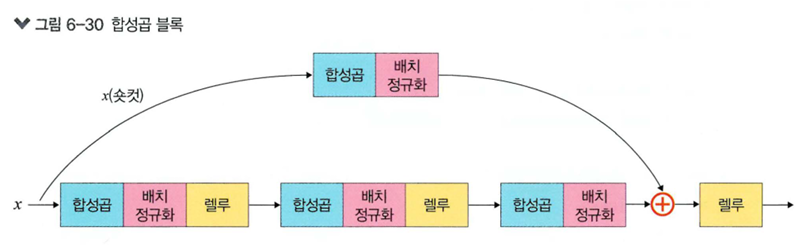

### ResNet 구현

In [2]:
#필요한 라이브러리 호출
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

- 네임드 튜플: 튜플의 자료형이지만 키 값으로 데이터 접근 가능

```
from collections import nametuple
Student = namedtuple('Student',['name','age','DOB'])
S = Student('홍길동','19','187')

print(S[1]) # 인덱스 접근 > 19 출력
print(S.name)  # 키 값 접근 > 홍길동 출력
```

In [46]:
# 이미지 데이터 전처리
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]), # 훈련 이미지 데이터 전처리
        'val': transforms.Compose([
            transforms.Resize(resize),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]) # 검증, 테스트 이미지 데이터 전처리
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [47]:
# 변수에 대한 값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [48]:
# 훈련과 테스트 데이터셋 불러오기
cat_directory = r'/content/drive/MyDrive/EURON/dogs-vs-cats/Cat/'
dog_directory = r'/content/drive/MyDrive/EURON/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [ i for i in images_filepaths if cv2.imread(i) is not None]

In [49]:
# 데이터셋을 위한 훈련, 검증, 테스트 용도로 분리
random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
test_images_filepaths = correct_images_filepaths[400:-10]
val_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 10 92


In [50]:
# 이미지에 대한 레이블 구분
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list = file_list
    self.transform = transform
    self.phase = phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path = self.file_list[idx]
    img = Image.open(img_path)
    img_transformed = self.transform(img, self.phase)

    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

In [51]:
# 이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform = ImageTransform(size, mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


In [52]:
# 데이터셋의 데이터를 메모리로 불러오기
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 0, 1, 1, 1, 0, 0])


In [53]:
from re import I
# 기본 블록 정의
class BasicBlock(nn.Module):
  expansion = 1
  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(out_channels)
      downsample = nn.Sequential(conv, bn)

    else:
      downsample = None
    self.downsample = downsample

  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2d(x)
    x = self.bn2(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i   # 아이덴티티 매핑(숏컷, 스킵 연결)
    x = self.relu(x)

    return x

In [54]:
# 병목 블록 정의 (ResNet50, 101, 152에서 사용)
class Bottleneck(nn.Module):
  expansion = 4

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1= nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride = stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.conv3 = nn.Conv2d(out_channels, self.expansion*out_channels,
                           kernel_size=1, stride=1, bias=False)
    self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, self.expansion*out_channels, kernel_size=1, stride=stride, bias = False)
      bn = nn.BatchNorm2d(self.expansion*out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None
    self.downsample = downsample

  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.conv3(x)
    x = self.bn3(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i
    x = self.relu(x)
    return x

In [55]:
# ResNet 모델 네트워크
class ResNet(nn.Module):
  def __init__(self, config, output_dim, zero_init_residual=False):
    super().__init__()

    block, n_blocks, channels=config
    self.in_channels = channels[0]
    assert len(n_blocks) == len(channels) == 4
    self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2,
                           padding = 3, bias = False)
    self.bn1 = nn.BatchNorm2d(self.in_channels)
    self.relu = nn.ReLU(inplace = True)
    self.maxpool = nn.MaxPool2d(kernel_size = 3, stride=2, padding=1)

    self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
    self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
    self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
    self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.fc = nn.Linear(self.in_channels, output_dim)

    if zero_init_residual:
      for m in self.modules():
        if isinstance(m, Bottleneck):
          nn.init.constant_(m.bn3.weight, 0)
        elif isinstance(m, BasicBlock):
          nn.init.constant_(m.bn2.weight, 0)

  def get_resnet_layer(self, block, n_blocks, channels, stride=1):
    layers = []
    if self.in_channels != block.expansion*channels:
      downsample = True
    else:
      downsample = False

    layers.append(block(self.in_channels, channels, stride, downsample))
    for i in range(1, n_blocks):
      layers.append(block(block.expansion*channels, channels))

    self.in_channels = block.expansion*channels
    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.avgpool(x)
    h = x.view(x.shape[0], -1)
    x = self.fc(h)
    return x, h

In [56]:
# ResNetConfig 정의
ResNetConfig = namedtuple('ResNetConfig',['block','n_blocks','channels'])

In [57]:
# 기본 블록을 사용하여 ResNetConfig 정의
resnet18_config = ResNetConfig(block = BasicBlock,
                               n_blocks = [2,2,2,2],
                               channels = [64, 128, 256, 512])

resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks = [3,4,6,3],
                               channels = [64, 128, 256, 512])

In [58]:
# 병목 블록을 사용하여 ResNetConfig 정의
resnet50_config = ResNetConfig(block = Bottleneck,
                               n_blocks=[3,4,6,3],
                               channels=[64,128, 256, 512])

resnet101_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3,4,23,3],
                                channels = [64, 128, 256, 512])

resnet152_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3,8,36,3],
                                channels = [64, 128, 256, 512])

In [59]:
# 사전훈련된 ResNet 모델 사용
pretrained_model = models.resnet50(pretrained = True)

In [60]:
# 사전훈련된 ResNet 네트워크 확인
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [61]:
# ResNet50 Config 사용한 ResNet 모델 사용
OUTPUT_DIM = 2 # 개와 고양이 클래스
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

직접 정의한 네트워크와 사전 정의된 네트워크가 같음

앞으로는 사전 훈련된 모델을 사용하는 것이 유용

In [62]:
# 옵티마이저와 손실 함수 정의
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [63]:
# 모델 학습 정확도 측정함수 정의
def calculate_topk_accuracy(y_pred, y, k=2):
  with torch.no_grad():
    batch_size=y.shape[0]
    _, top_pred = y_pred.topk(k,1)
    top_pred = top_pred.t()
    correct = top_pred.eq(y.view(1,-1).expand_as(top_pred))
    correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
    acc_1 = correct_1 / batch_size
    acc_k = correct_k / batch_size
  return acc_1, acc_k

In [64]:
# 모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, scheduler, device):
  epoch_loss = 0
  epoch_acc_1 = 0
  epoch_acc_5 = 0
  model.train()
  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred[0], y)

    acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc_1 += acc_1.item()
    epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator)
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [65]:
# 모델 평가함수 정의
def evaluate(mode1 , iterator, criterion, device):
  epoch_loss = 0
  epoch_acc_1 = 0
  epoch_acc_5 = 0

  model.eval ()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device)
      y_pred = model(x)
      loss = criterion(y_pred[0], y)

      acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
      epoch_loss += loss.item()
      epoch_acc_1 += acc_1.item()
      epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator)
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [66]:
# 모델 학습 시간 측정 함수 정의
def epoch_time(strat_time, end_time):
  elapsed_time = end_time - strat_time
  elapsed_mins = int(elapsed_time/60)
  elapsed_secs = int(elapsed_time - (elapsed_mins*60))
  return elapsed_mins, elapsed_secs

In [67]:
# 모델 학습
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
  start_time = time.monotonic()

  train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer, criterion, scheduler, device)
  valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion, device)

  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/EURON/ResNet-model.pt')

  end_time = time.monotonic()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | ' \
        f'Train Acc @5: {train_acc_5*100:6.2f}%')
  print(f'\Valid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \
        f'Train Acc @5: {valid_acc_5*100:6.2f}%')

<>:22: SyntaxWarning: invalid escape sequence '\V'
<>:22: SyntaxWarning: invalid escape sequence '\V'
/tmp/ipykernel_519/4054260574.py:22: SyntaxWarning: invalid escape sequence '\V'
  print(f'\Valid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \


Epoch: 01 | Epoch Time: 4m 15s
	Train Loss: 0.684 | Train Acc @1:  58.17% | Train Acc @5: 100.00%
\Valid Loss: 0.644 | Valid Acc @1:  70.00% | Train Acc @5: 100.00%
Epoch: 02 | Epoch Time: 4m 13s
	Train Loss: 0.682 | Train Acc @1:  56.97% | Train Acc @5: 100.00%
\Valid Loss: 0.619 | Valid Acc @1:  70.00% | Train Acc @5: 100.00%
Epoch: 03 | Epoch Time: 4m 16s
	Train Loss: 0.681 | Train Acc @1:  58.89% | Train Acc @5: 100.00%
\Valid Loss: 0.654 | Valid Acc @1:  70.00% | Train Acc @5: 100.00%
Epoch: 04 | Epoch Time: 4m 6s
	Train Loss: 0.680 | Train Acc @1:  58.41% | Train Acc @5: 100.00%
\Valid Loss: 0.679 | Valid Acc @1:  60.00% | Train Acc @5: 100.00%
Epoch: 05 | Epoch Time: 4m 6s
	Train Loss: 0.677 | Train Acc @1:  59.38% | Train Acc @5: 100.00%
\Valid Loss: 0.714 | Valid Acc @1:  60.00% | Train Acc @5: 100.00%
Epoch: 06 | Epoch Time: 4m 14s
	Train Loss: 0.676 | Train Acc @1:  59.86% | Train Acc @5: 100.00%
\Valid Loss: 0.724 | Valid Acc @1:  40.00% | Train Acc @5: 100.00%
Epoch: 07 | 

In [72]:
# 테스트 데이터셋을 이용한 모델 예측
import pandas as pd
id_list = []
pred_list = []
id = 8
with torch.no_grad():
  for test_path in test_images_filepaths:
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean , std)
    img = transform(img, phase= 'val')
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs[0], dim=1)[:,1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True )
res.to_csv( '/content/drive/MyDrive/EURON/ResNet.csv', index=False)
res.head(10)

,id,label
0,100,0.488644
1,104,0.500305
2,11,0.488834
3,111,0.491418
4,112,0.435353
5,118,0.464764
6,119,0.490858
7,119,0.565248
8,123,0.531257
9,126,0.442905


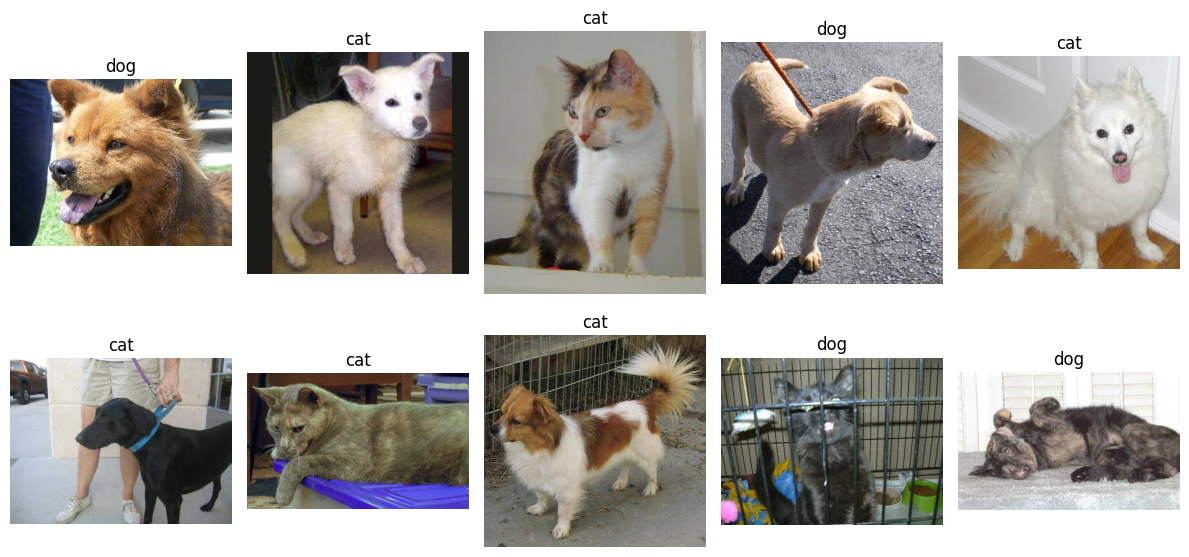

In [78]:
# 모델 예측에 대한 결과 출력
class_ = {0:'cat', 1:'dog'}

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols + (1 if len(images_filepaths) % cols != 0 else 0)
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        _id = image_filepath.split('/')[-1].split('.')[1]
        label_prob = res.loc[res['id'] == _id, 'label'].values[0]

        if label_prob > 0.5:
            label = 1
        else:
            label = 0

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()

    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths[:10])